<a href="https://colab.research.google.com/github/SubodhWalondre-1/Machine-Vision-Lab/blob/main/Prac_06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.7/170.7 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.4/70.4 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 32.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.3/51.3 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 32.8 MB/s eta 0:00:00
26-07-21 05:42:50 - Directory /root/.deepface has been created
26-07-21 05:42:50 - Directory /root/.deepface/weights has been created


Saving angry.jpg to angry.jpg
26-07-21 05:43:07 - 🔗 facial_expression_model_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/facial_expression_model_weights.h5 to /root/.deepface/weights/facial_expression_model_weights.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/facial_expression_model_weights.h5
To: /root/.deepface/weights/facial_expression_model_weights.h5
100%|██████████| 5.98M/5.98M [00:00<00:00, 102MB/s]


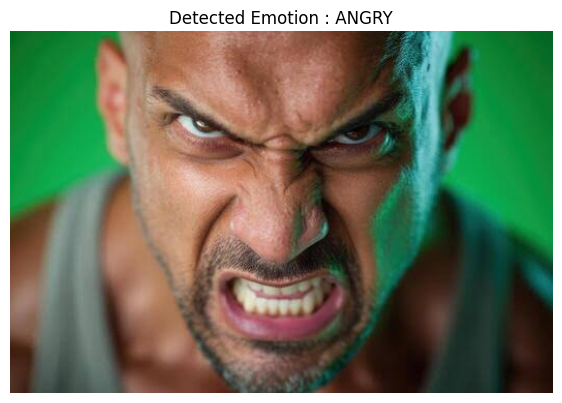


Emotion Confidence Scores
------------------------------
angry     : 98.14%
disgust   : 1.33%
fear      : 0.52%
happy     : 0.00%
sad       : 0.01%
surprise  : 0.00%
neutral   : 0.00%

Dominant Emotion: angry


In [ ]:
# ================================
# Customer Emotion Classification
# Using Pre-trained DeepFace Model
# ================================

# Install required libraries
!pip -q install deepface opencv-python matplotlib

import cv2
import matplotlib.pyplot as plt
from google.colab import files
from deepface import DeepFace

# Upload image
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

# Read image
img = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Emotion Detection
result = DeepFace.analyze(
    img_path=image_path,
    actions=['emotion'],
    enforce_detection=False
)

# If multiple faces, take first result
if isinstance(result, list):
    result = result[0]

emotion = result['dominant_emotion']

# Display image
plt.figure(figsize=(7,7))
plt.imshow(img_rgb)
plt.title(f"Detected Emotion : {emotion.upper()}")
plt.axis("off")
plt.show()

# Print all emotion scores
print("\nEmotion Confidence Scores")
print("-"*30)
for emo, score in result['emotion'].items():
    print(f"{emo:10s}: {score:.2f}%")

print("\nDominant Emotion:", emotion)